<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net/index.php/qworld/" target="_blank"><img src="../images/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by Özlem Salehi
        </td>        
</tr></table>

<table width="100%"><tr><td style="color:#bbbbbb;background-color:#ffffff;font-size:11px;font-style:italic;text-align:right;">This cell contains some macros. If there is a problem with displaying mathematical formulas, please run this cell to load these macros. </td></tr></table>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\qgate}[1]{ \mathop{\textit{#1} } }$

# Solutions for PennyLane Introduction

<a id="task1"></a>
### Task 1
    
Create a quantum circuit with 10 qubits. 

1. Apply $\qgate{H}$ gate to qubit 0
2. Apply nine $\qgate{CNOT}$ gates where qubit $0$ is the control and qubit $i$ is the target for $i=1\cdots9$.

Draw your circuit.

### Solution

(<Figure size 1300x1100 with 1 Axes>, <Axes: >)

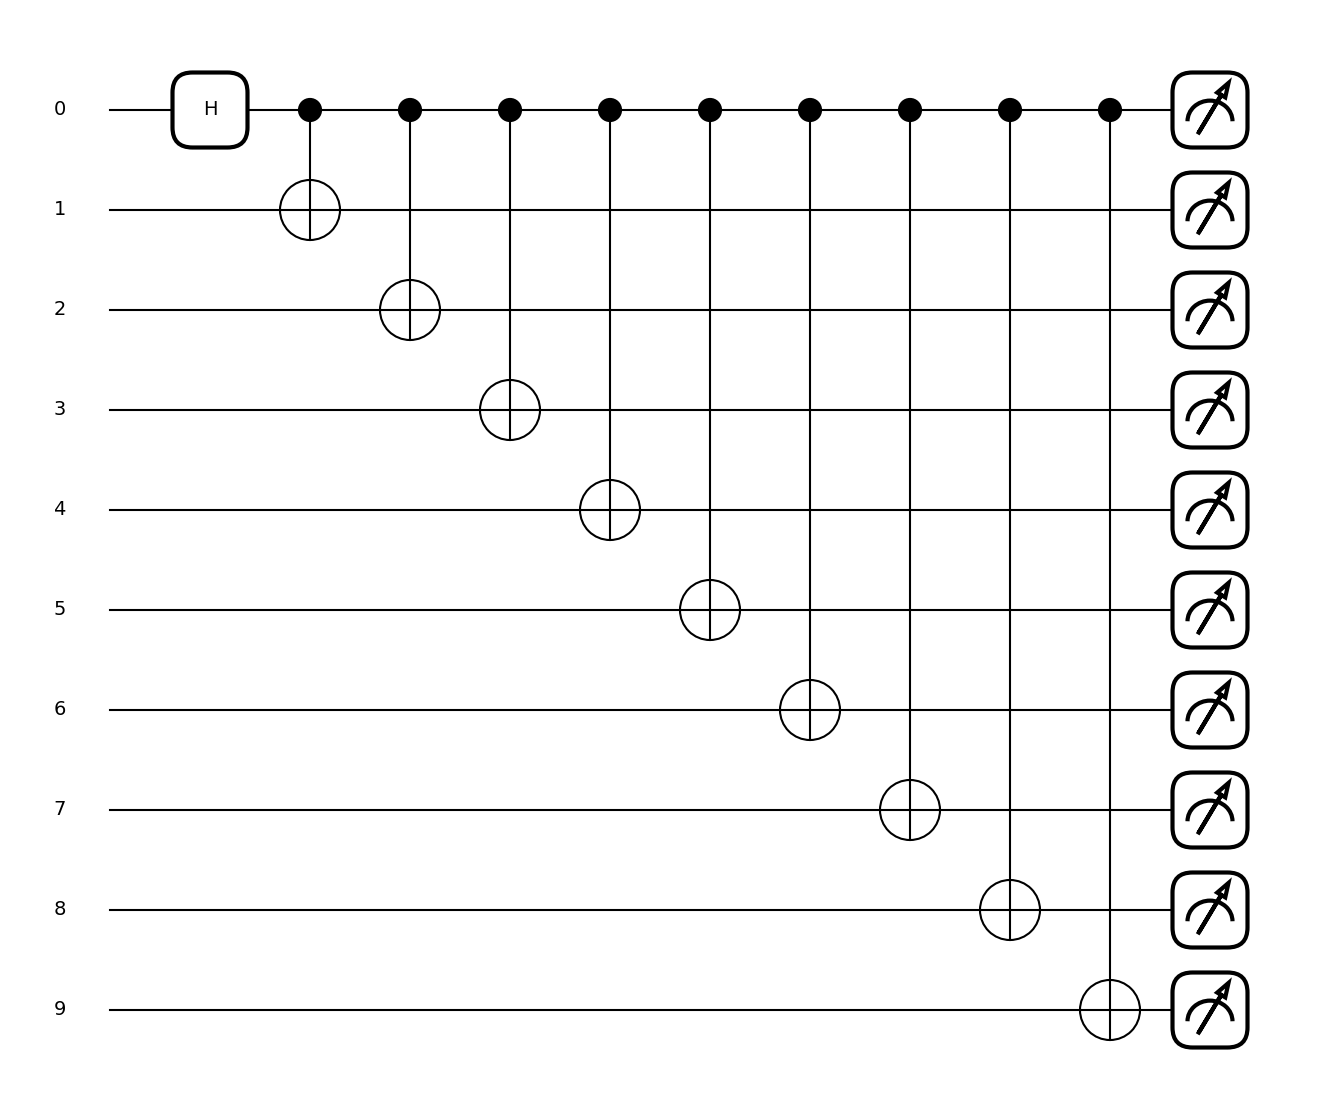

In [11]:
import pennylane as qml

# Create a device with 10 qubits
dev = qml.device("default.qubit", wires=10)

@qml.qnode(dev)
def circuit():
    # Apply H to qubit 0
    qml.Hadamard(wires=0)

    # Apply CX gates
    for i in range(1,10):
        qml.CNOT(wires=[0,i])

    return qml.state()

qml.draw_mpl(circuit)()

<a id="task2"></a>
### Task 2
    
Create a quantum circuit with 10 qubits. 

1. Apply $\qgate{H}$ gates to all qubits.
2. Apply $\qgate{X}$ gate to qubit 0 controlled by qubits 1-9
2. Apply $\qgate{H}$ gates to all qubits.

Draw your circuit.

### Solution

(<Figure size 600x1100 with 1 Axes>, <Axes: >)

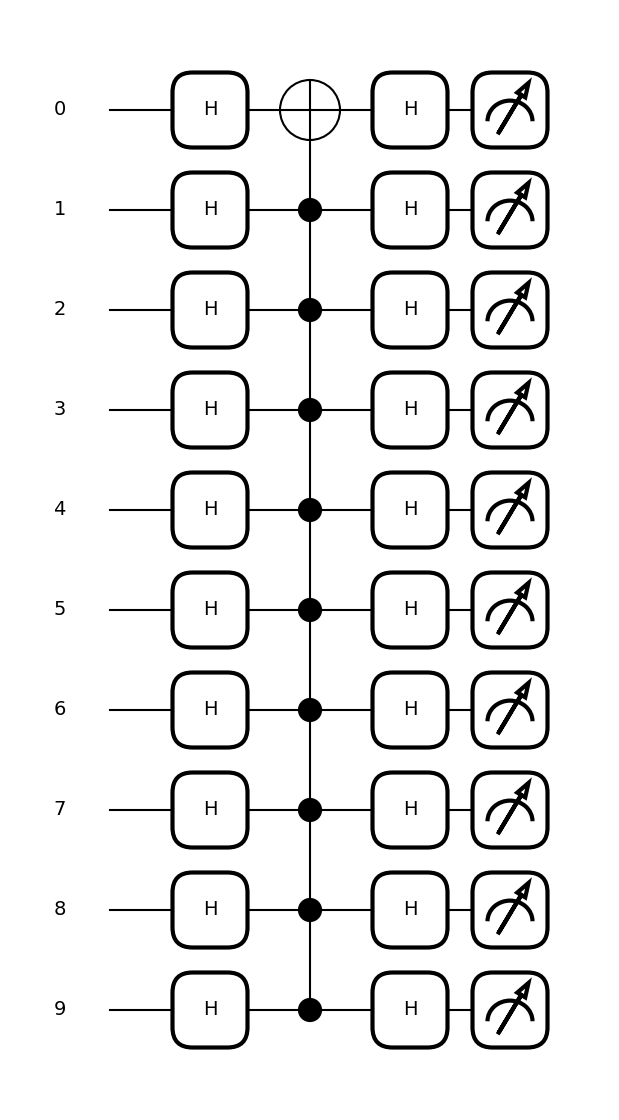

In [12]:
import pennylane as qml

# Create a device with 10 qubits
dev = qml.device("default.qubit", wires=10)

@qml.qnode(dev)
def circuit():
    # Apply H to all qubits
    for w in range(10):
        qml.Hadamard(wires=w)

    # Create a controlled-NOT gate with 9 control qubits
    # Qubits 1-9 are the control and qubit 0 is the target
    qml.ctrl(qml.PauliX(wires=0), control=list(range(1,10)))

    # Apply H to all qubits
    for w in range(10):
        qml.Hadamard(wires=w)

    return qml.state()

qml.draw_mpl(circuit)()

<a id="task3"></a>
### Task 3
    
Implement the circuit in Task 1. Measure all the qubits and simulate your circuit for 1000 times.

### Solution

In [13]:
import pennylane as qml
import pandas as pd

# Create a device with 10 qubits
dev = qml.device("default.qubit", wires=10)

@qml.set_shots(shots=1000)
@qml.qnode(dev)
def circuit():
    qml.Hadamard(wires=0)

    for i in range(1, 10):
        qml.CNOT(wires=[0, i])

    return qml.counts(wires=list(range(10)))

# Run the circuit
result = circuit()

# Create the dataframe
df = pd.DataFrame({
    "State": [str(state) for state in result.keys()],
    "Counts": [int(count) for count in result.values()]
})

# Add probabilities
total_shots = df["Counts"].sum()
df["Probability"] = df["Counts"] / total_shots

# Display the table
display(df)

,State,Counts,Probability
0,0000000000,500,0.5
1,1111111111,500,0.5


<a id="task4"></a>
### Task 4
    
Create a quantum circuit with 4 qubits. Apply Hadamard gate to each qubit and $\qgate{CZ}$ gate to qreg[3] and qreg[2]. Use the simulator without measuring the circuit. Check the entries with negative sign.

### Solution

In [14]:
import pennylane as qml
import numpy as np

# Create a device with 4 qubits
dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev)
def circuit():
    # Apply H gate to all qubits
    for w in range(4):
        qml.Hadamard(wires=w)

    # Apply CZ gate to qreg[3] and qreg[2]
    qml.CZ(wires=[3,2])

    return qml.state()

state = circuit()
print(np.round(state, 3))

[ 0.25+0.j  0.25+0.j  0.25+0.j -0.25+0.j  0.25+0.j  0.25+0.j  0.25+0.j
 -0.25+0.j  0.25+0.j  0.25+0.j  0.25+0.j -0.25+0.j  0.25+0.j  0.25+0.j
  0.25+0.j -0.25+0.j]


The states $\ket{1100}$, $\ket{1101}$, $\ket{1110}$, $\ket{1111}$ have the negative sign.